### Open-air area classifier

In [ ]:
import os
import time
import random

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import Image

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import keras

from keras_tuner import HyperParameters, Objective
from keras_tuner.tuners import RandomSearch

In [ ]:
# Zadanie 6
# 1)
data = {}
with np.load("Intel_Image.npz") as f:
    data["train_img"] = f["train_img"]
    data["train_lab"] = f["train_lab"]
    data["test_img"] = f["test_img"]
    data["test_lab"] = f["test_lab"]

# 2)
X_train = data["train_img"]
y_train = data["train_lab"]
X_test = data["test_img"]
y_test = data["test_lab"]

# 3)
# Data is ~ 14k recods for train set and 3k for test set. Each record is 126x126 array with 3 values representing R, G, B channels values
print(f"Shapes of arrays: train_set: ({X_train.shape}) test_set: ({X_test.shape})")
print(f"Types of arrays: train_set: ({X_train.dtype}) test_set: ({X_test.dtype})")
print(f"Check wheter the data in 126x126 2D array is alredy scaled: train set min val: {X_train.min()} max val: {X_train.max()}")
print(f"Check wheter the data in 126x126 2D array is alredy scaled: test set min val: {X_test.min()} max val: {X_test.max()}\n")


NUM_CLASSES_TRAIN = len(set(y_train))
NUM_CLASSES_TEST = len(set(y_test))
if NUM_CLASSES_TRAIN != NUM_CLASSES_TEST:
    raise ValueError("Number of unique classes in train set and test set are different")

print(f"Types of labels: train: ({y_train.dtype}) test: ({y_test.dtype})")
print(f"Labels range from {y_train.min()} to {y_test.max()} - total unique labels: {NUM_CLASSES_TRAIN}")

Shapes of arrays: train_set: ((14034, 126, 126, 3)) test_set: ((3000, 126, 126, 3))
Types of arrays: train_set: (float32) test_set: (float32)
Check wheter the data in 126x126 2D array is alredy scaled: train set min val: 0.0 max val: 1.0
Check wheter the data in 126x126 2D array is alredy scaled: test set min val: 0.0 max val: 1.0

Types of labels: train: (int8) test: (int8)
Labels range from 0 to 5 - total unique labels: 6


Text(0.5, 1.0, 'Rozkład klas w zbiorze treningowym')

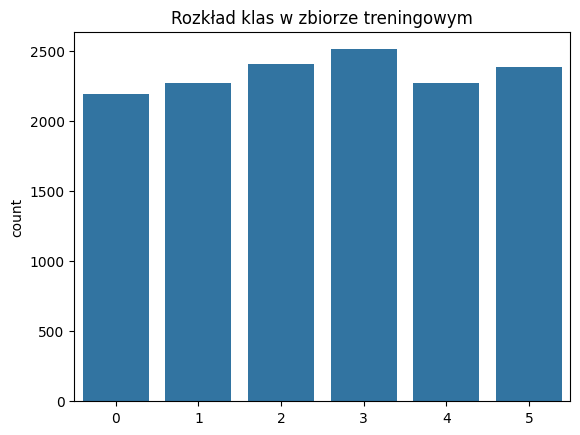

In [3]:
sns.countplot(x=y_train).set_title("Rozkład klas w zbiorze treningowym")

Text(0.5, 1.0, 'Rozkład klas w zbiorze testowym')

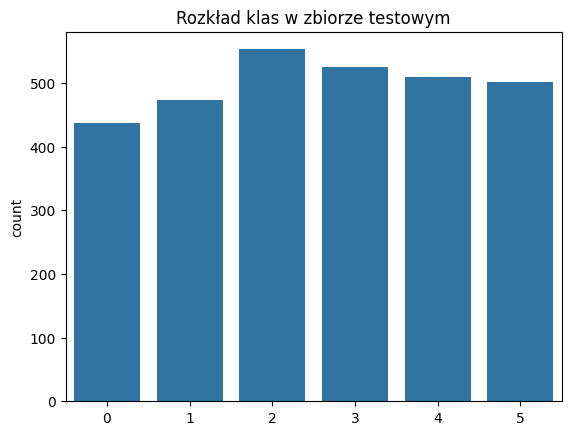

In [4]:
sns.countplot(x=y_test).set_title("Rozkład klas w zbiorze testowym")

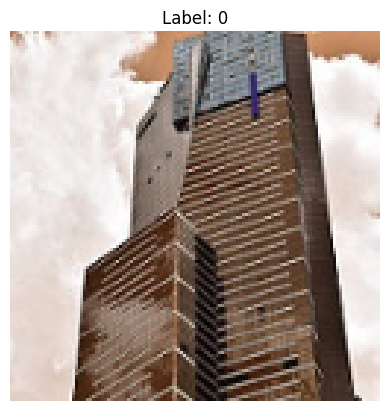

In [5]:
# 4)
plt.imshow(X_test[0], interpolation='nearest')
plt.axis("off")
plt.title(f"Label: {y_train[0]}")
plt.show()

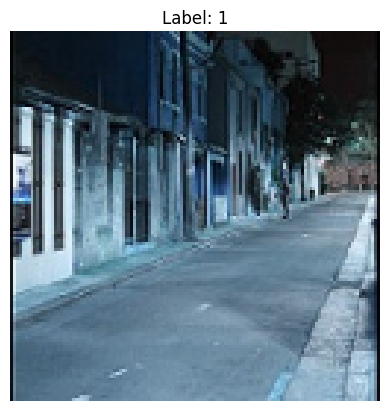

In [6]:
last_rec_idx = len(X_test) -1
plt.imshow(X_test[last_rec_idx], interpolation='nearest')
plt.axis("off")
plt.title(f"Label: {y_train[last_rec_idx]}")
plt.show()

In [7]:
# Zadanie 7
# 1)
model = keras.models.Sequential([
    keras.layers.Input(shape=(126, 126, 3)),
    keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation="relu"),
    keras.layers.Dense(units=64, activation="relu"),
    keras.layers.Dense(units=NUM_CLASSES_TRAIN, activation="softmax")
])

2026-04-16 21:26:55.689810: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-16 21:26:55.689839: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-16 21:26:55.689844: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1776367615.690128 4893813 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1776367615.690430 4893813 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,715,430 (14.17 MB)

 Trainable params: 3,715,430 (14.17 MB)

 Non-trainable params: 0 (0.00 B)

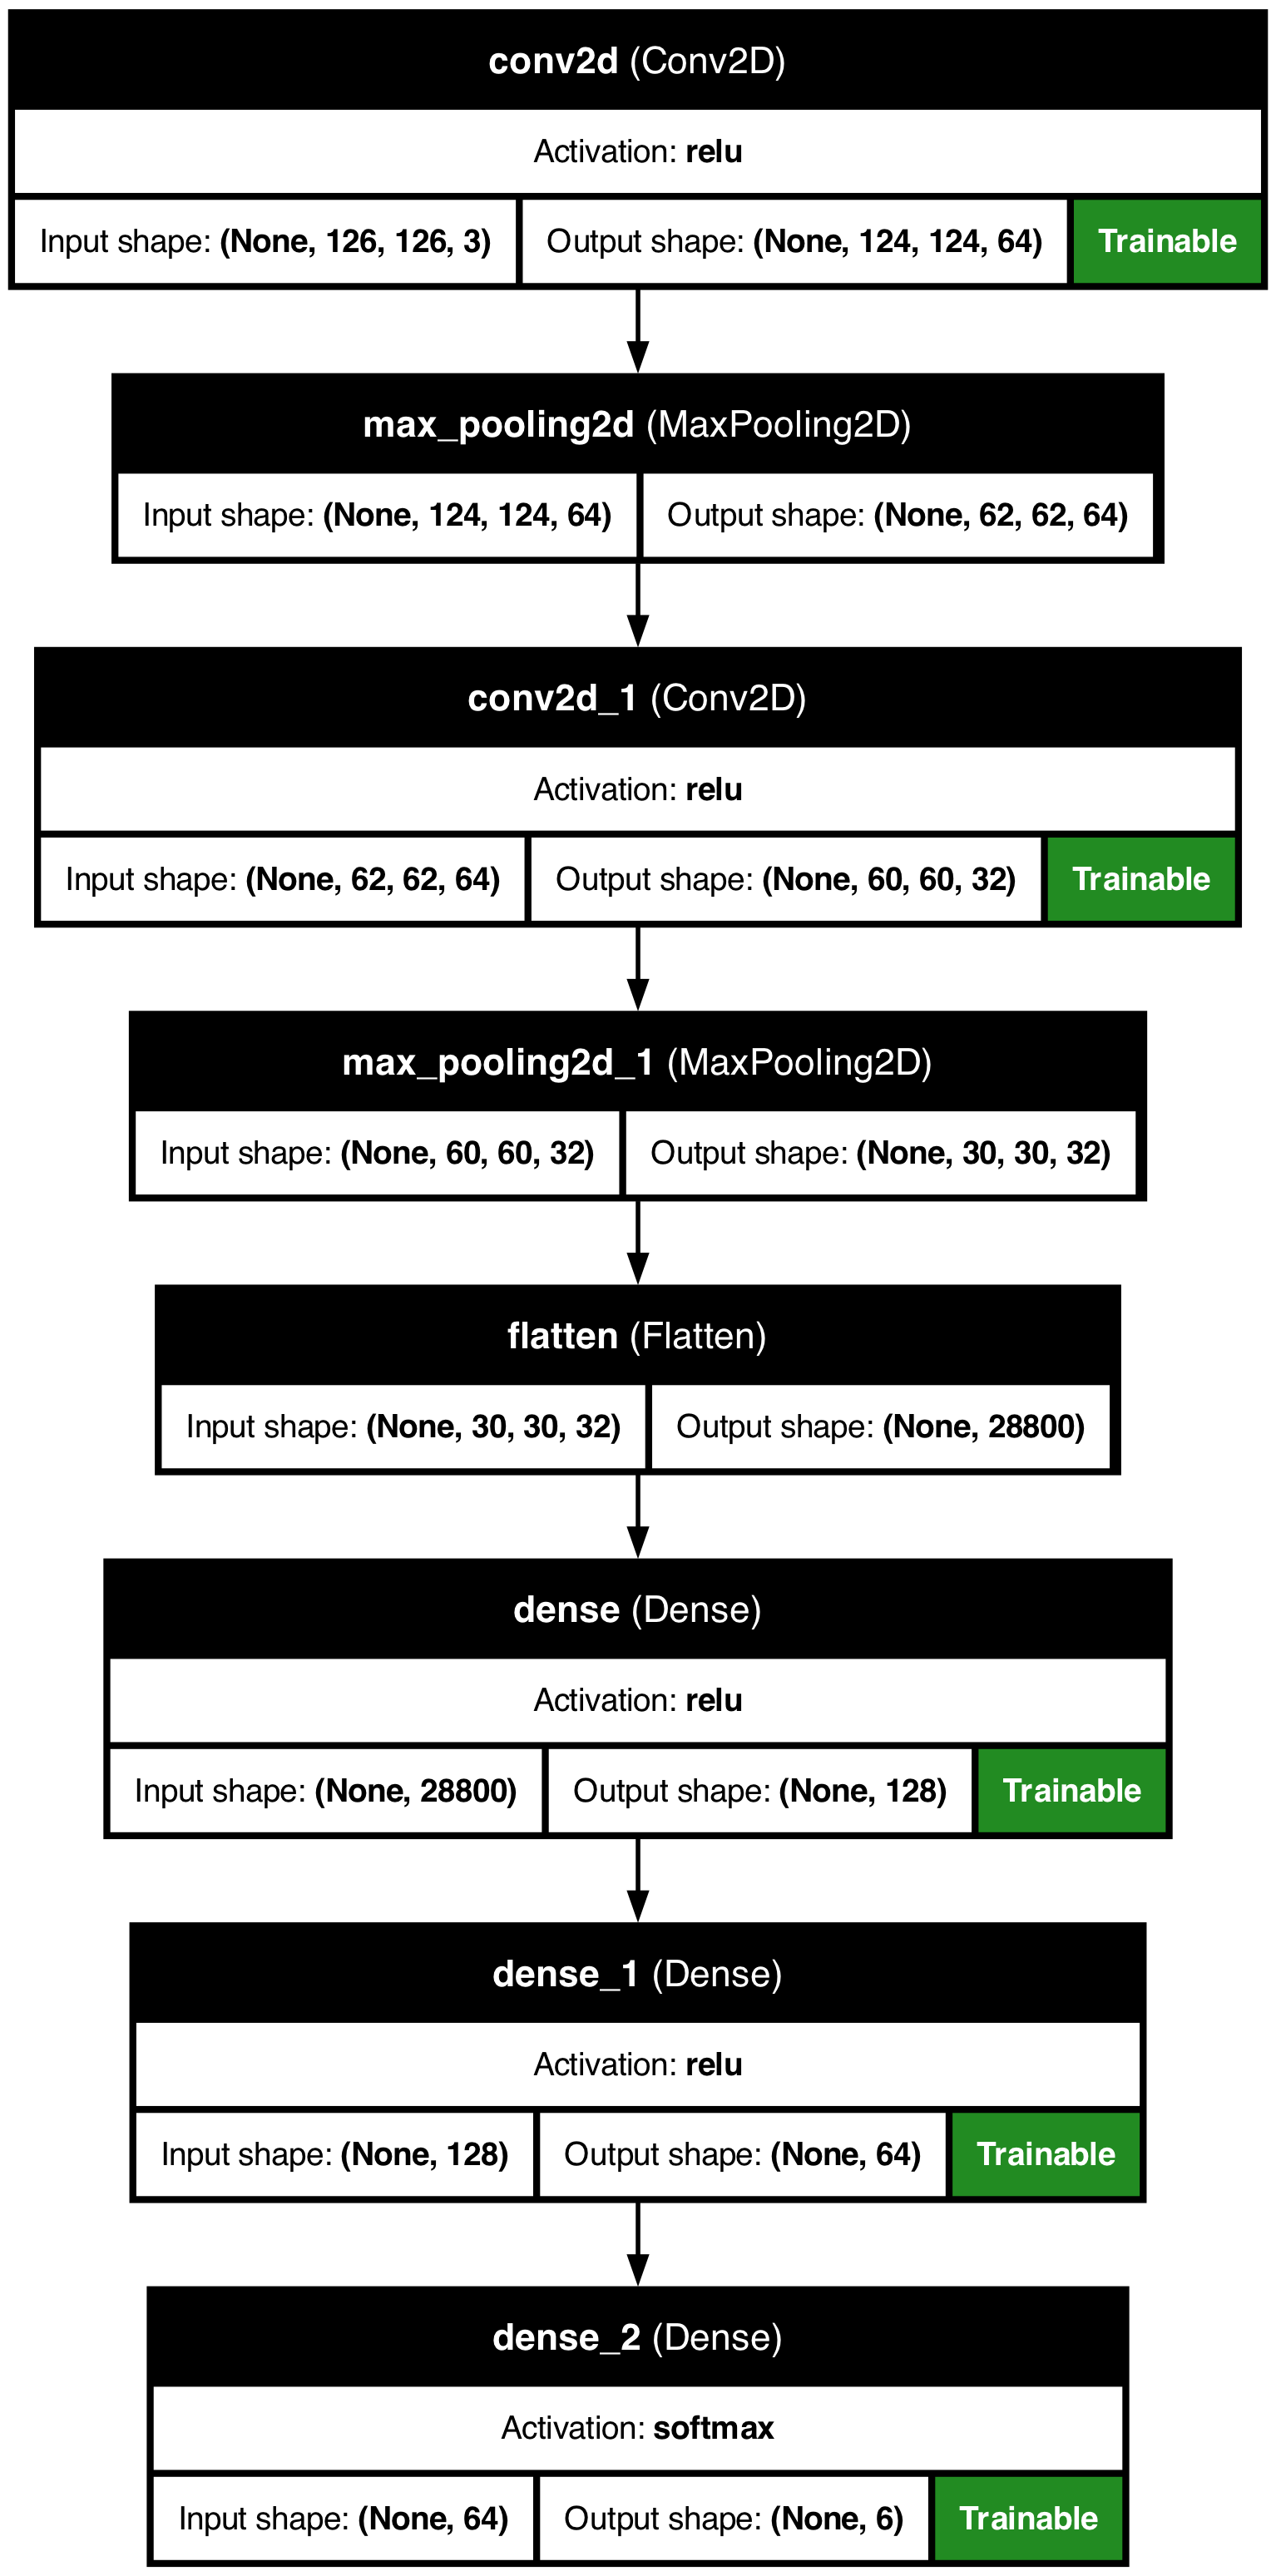

In [8]:
# 2) 
model.summary()
keras.utils.plot_model(model, "openair_cnn.png", show_shapes=True, show_layer_names=True, show_layer_activations=True, show_trainable=True)
Image(filename="openair_cnn.png", width=400)

In [9]:
# 3)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# 4)
root_logdir = os.path.join(os.curdir, "my_logs")
logdir = os.path.join(root_logdir, "run_{}".format(time.time()))

%load_ext tensorboard
%tensorboard --logdir {root_logdir}

history = model.fit(
    X_train, 
    y_train, 
    epochs=20, 
    validation_data=(X_test, y_test), 
    callbacks=[
        keras.callbacks.TensorBoard(log_dir=logdir),
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max", restore_best_weights=True),
        keras.callbacks.ModelCheckpoint("openair_cnn.keras", save_best_only=True)
    ]
)

Reusing TensorBoard on port 6007 (pid 94020), started 2 days, 22:02:25 ago. (Use '!kill 94020' to kill it.)

Epoch 1/20


2026-04-16 21:26:57.944764: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


439/439 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.4890 - loss: 1.3800 - val_accuracy: 0.5610 - val_loss: 1.1656
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.5878 - loss: 1.0890 - val_accuracy: 0.5973 - val_loss: 1.0624
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6218 - loss: 1.0204 - val_accuracy: 0.6283 - val_loss: 1.0166
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6426 - loss: 0.9759 - val_accuracy: 0.6390 - val_loss: 1.0095
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6596 - loss: 0.9390 - val_accuracy: 0.6347 - val_loss: 0.9637
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6727 - loss: 0.9049 - val_accuracy: 0.6577 - val_loss: 0.9281
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6848 - loss: 0.8764 - val_accuracy: 0.6777 - val_loss: 0.9082
Epoch 8/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6942 - loss: 0.8526 - val_accuracy: 0.67

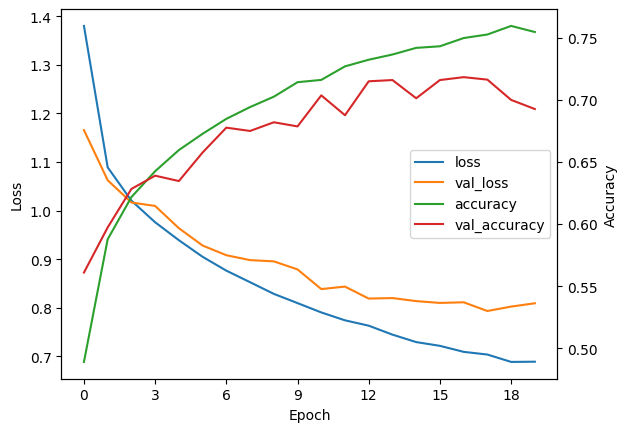

In [ ]:
# 5)
def plot_learning_curves(history):
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    
    l1, = ax1.plot(history.history['loss'], '-', color='C0', label='loss')
    l2, = ax1.plot(history.history['val_loss'], '-', color='C1', label='val_loss')

    l3, = ax2.plot(history.history['accuracy'], '-', color='C2', label='accuracy')
    l4, = ax2.plot(history.history['val_accuracy'], '-', color='C3', label='val_accuracy')
    
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel('Loss')

    ax2.set_ylabel('Accuracy')
    
    plt.legend(handles=[l1, l2, l3, l4], loc='center right')
    return fig, ax1, ax2

fig, ax1, ax2 = plot_learning_curves(history)
plt.show()

    


In [11]:
# 6)
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# 7)
# Display a few Images from test set
first_rand_idx = random.randint(a=0, b=len(test_preds) - 1)
sec_rand_idx = random.randint(a=0, b=len(test_preds) - 1)
third_rand_idx = random.randint(a=0, b=len(test_preds) - 1)

439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [12]:
def plot_predicted_image_with_softmax_probas(idx: int) -> None:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(X_test[idx], interpolation='nearest')
    plt.axis("off")
    plt.title(f"Predicted label: {np.argmax(test_preds[idx])}, true label {y_test[idx]}")

    plt.subplot(1, 2, 2)
    plt.bar(range(NUM_CLASSES_TEST), test_preds[idx])
    plt.xticks(range(NUM_CLASSES_TEST))
    plt.xlabel('Digit')
    plt.ylabel('Probability')
    plt.title('Softmax Probabilities')
    plt.subplots_adjust(wspace=0.4)
    plt.show()

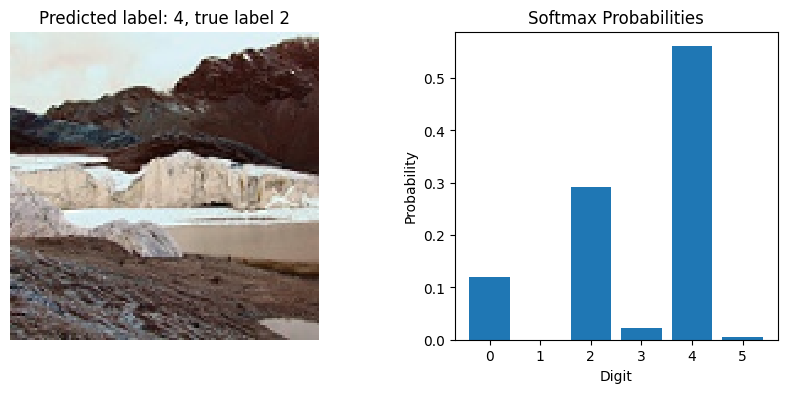

In [13]:
plot_predicted_image_with_softmax_probas(first_rand_idx)

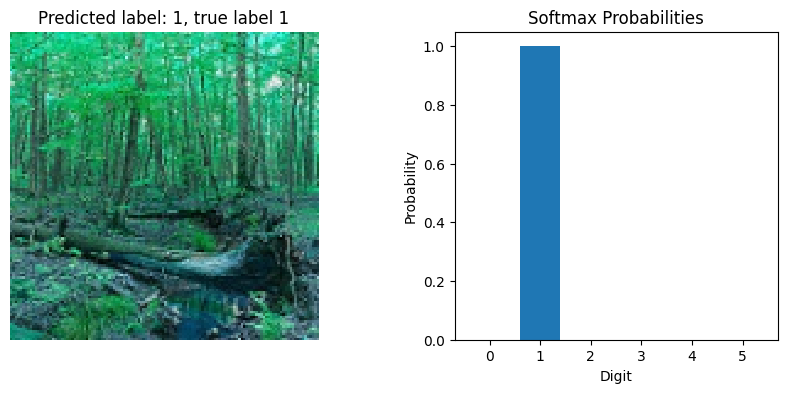

In [14]:
plot_predicted_image_with_softmax_probas(sec_rand_idx)

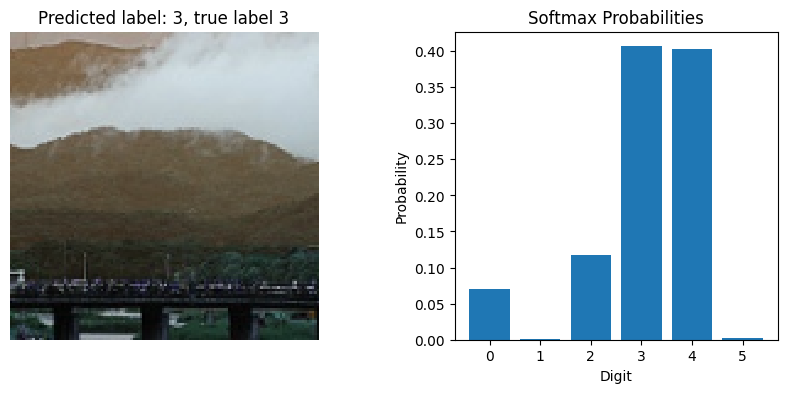

In [15]:
plot_predicted_image_with_softmax_probas(third_rand_idx)

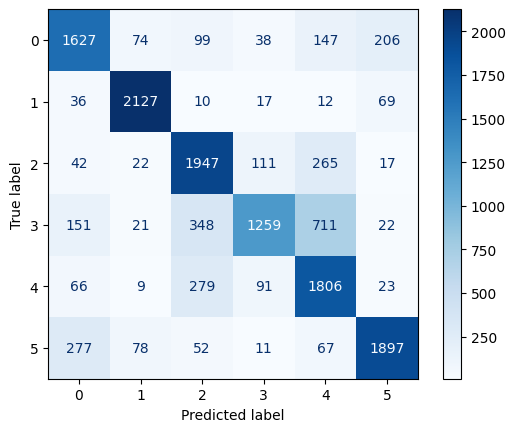

In [16]:
# 8) 
y_train_preds_to_labes = np.argmax(train_preds, axis=1)

# train set conf matrix
cm_train_set = confusion_matrix(y_true=y_train, y_pred=y_train_preds_to_labes)
disp_train_cm = ConfusionMatrixDisplay(cm_train_set)
disp_train_cm.plot(cmap="Blues")

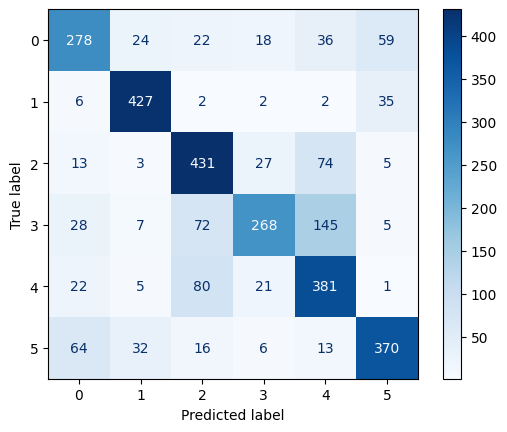

In [17]:
# test set conf matrix
y_test_preds_to_labes = np.argmax(test_preds, axis=1)

cm_train_set = confusion_matrix(y_true=y_test, y_pred=y_test_preds_to_labes)
disp_train_cm = ConfusionMatrixDisplay(cm_train_set)
disp_train_cm.plot(cmap="Blues")

In [18]:
acc_train = accuracy_score(y_true=y_train, y_pred=y_train_preds_to_labes)
acc_test = accuracy_score(y_true=y_test, y_pred=y_test_preds_to_labes)

print(f"Train set acc: {acc_train}, test set acc: {acc_test}")

Train set acc: 0.7597976343166596, test set acc: 0.7183333333333334


In [ ]:
# 9) First training summary:
# Accuracy on ~0.71 is a good baseline to start to work with. The highest upside that allows initial training to happen is correct learning rate, in this case its 1e-5. With 1e-4 the model was not usable at all with low
# acc and plot that was looking like complete chaos both loss and acc metrics.

# The next thing to do is to apply regularization and hypeparameter tuning to the model, as the base model was pretty simple with the architecture and variety of layers.


In [ ]:
def build_model(hp: HyperParameters):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(126, 126, 3)))

    n_conv_layers = hp.Int("n_conv", min_value=1, max_value=4, step=1)
    for _ in range(n_conv_layers):
        model.add(keras.layers.Conv2D(filters=hp.Choice("filters", [32, 64, 128]), kernel_size=3, activation=hp.Choice("activation", ["relu", "selu"])))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(keras.layers.Flatten())
    
    n_dens_layers = hp.Int("n_dense", min_value=0, max_value=3, step=1)
    n_neurons = hp.Int("n_neurons", min_value=24, max_value=256, step=24)
    for _ in range(n_dens_layers):
        model.add(keras.layers.Dense(n_neurons, activation=hp.Choice("activation", ["swish", "selu", "relu"])))

    if hp.Boolean("dropout"):
        model.add(keras.layers.Dropout(rate=hp.Choice("rate", [0.1, 0.15, 0.2, 0.25])))
    
    model.add(keras.layers.Dense(units=NUM_CLASSES_TRAIN, activation="softmax"))

    lr = hp.Choice("learning_rate", values=[1e-3, 1e-4, 1e-5, 3e-4])
    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


objective = Objective("val_accuracy", direction="max")
tuner = RandomSearch(
    build_model, 
    objective=objective,
    max_trials=5,
    executions_per_trial=3,
    directory='keras_tuner',
    project_name='openair',
)

# Heavy training line comment out if necessary
tuner.search(
    X_train, 
    y_train, 
    epochs=50,
    validation_data=(X_test, y_test), 
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, mode="max", restore_best_weights=True)
    ]
)

best_model = tuner.get_best_models(num_models=1)[0]
print(best_model.evaluate(X_test, y_test))

Reloading Tuner from keras_tuner/openair/tuner0.json


/Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8120 - loss: 0.5725
[0.5724598169326782, 0.8119999766349792]


In [ ]:
# Tunner summary
# Trial 5 Complete [00h 10m 27s]
# val_accuracy: 0.6543333331743876

# Best val_accuracy So Far: 0.8107777635256449
# Total elapsed time: 03h 02m 29s
# /Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 26 variables. 
#   saveable.load_own_variables(weights_store.get(inner_path))
# 94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8120 - loss: 0.5725
# [0.5724598169326782, 0.8119999766349792]


In [ ]:
# Display best params from the tuner search
tuner.get_best_hyperparameters()[0].values

{'n_conv': 4,
 'filters': 32,
 'activation': 'selu',
 'n_dense': 3,
 'n_neurons': 192,
 'dropout': True,
 'learning_rate': 0.0001,
 'rate': 0.1}

In my case best params were:
{
 'n_conv': 4,
 'filters': 32,
 'activation': 'selu',
 'n_dense': 3,
 'n_neurons': 192,
 'dropout': True,
 'learning_rate': 0.0001,
 'rate': 0.1
}

In [26]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = build_model(best_hp)

best_model_history = best_model.fit(
    X_train, 
    y_train, 
    epochs=50, 
    validation_data=(X_test, y_test), 
    callbacks=[
        keras.callbacks.TensorBoard(log_dir=logdir),
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max", restore_best_weights=True),
        keras.callbacks.ModelCheckpoint("openair_best_cnn.keras", save_best_only=True)
    ]
)

Epoch 1/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.6030 - loss: 1.0867 - val_accuracy: 0.5040 - val_loss: 1.3066
Epoch 2/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.7273 - loss: 0.7310 - val_accuracy: 0.7077 - val_loss: 0.8226
Epoch 3/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.7721 - loss: 0.6153 - val_accuracy: 0.7777 - val_loss: 0.6442
Epoch 4/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.8018 - loss: 0.5395 - val_accuracy: 0.7740 - val_loss: 0.6753
Epoch 5/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.8238 - loss: 0.4852 - val_accuracy: 0.7673 - val_loss: 0.6513
Epoch 6/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.8379 - loss: 0.4415 - val_accuracy: 0.7320 - val_loss: 0.7566
Epoch 7/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.8554 - loss: 0.4010 - val_accuracy: 0.8067 - val_loss: 0.5529
Epoch 8/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.8660 - loss: 0.3698 - 

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Epoch', ylabel='Loss'>,
 <Axes: ylabel='Accuracy'>)

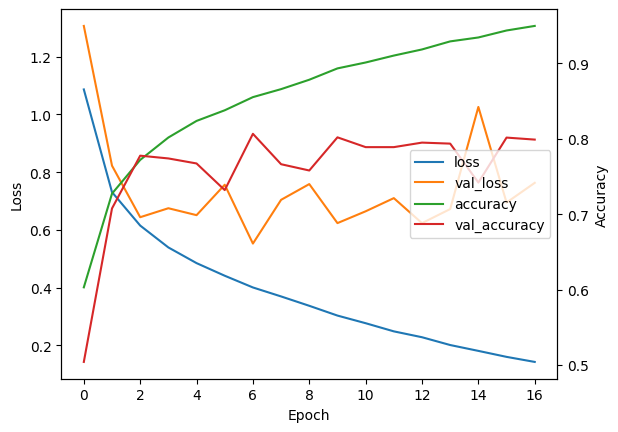

In [27]:
plot_learning_curves(best_model_history)

Model still overfitts heavy - accuracy on training set sky rocket above 0.9 where val_accuracy has very spiky structure and lands just on 0.8. What is recommended in the future is adding more regularization or data augumentation layers.